# Определение ботов по событиям

**Цель:** получить максимальный Precision при Recall ≥ 70%, соблюдая окно наблюдения каждой cookie.
Весь код решения, проверки, эксперименты и пояснения находятся в этом ноутбуке.
Используются классические ML-модели и локальные библиотеки; внешних API и LLM в пайплайне нет.

**Как запустить:** установить `requirements.txt`, выбрать Python из этого окружения и выполнить
**Restart Kernel → Run All**. Рабочая папка должна содержать `data/`, `sample_submission.csv`
и предоставленный организаторами `metric.py`. Baseline исходного quickstart полностью воспроизводится ниже; отдельный файл quickstart для запуска не нужен. Другие `.py`-скрипты, готовые признаки и сохранённые модели не нужны.

Запуск занимает несколько минут на CPU. На диск записывается только **`submission.csv`**;
таблицы и графики остаются в выводах ноутбука. Проверенное окружение: Python 3.13.7, 4 CPU-потока.

Порядок работы: данные и окна → метрика → признаки и проверки → временная валидация →
модели и отдельные группы признаков → ошибки и устойчивость → финальное обучение и submission.

Подготовка окружения из терминала (Python 3.13):

```bash
python -m venv .venv
.venv/bin/python -m pip install -r requirements.txt
```

После установки открыть этот ноутбук и выбрать ядро Python из созданного `.venv`.


## 1. Окружение и воспроизводимость

Фиксируем seed=42; для исходного RandomForest сохраняем seed=0 из quickstart.
Абсолютные даты и идентификаторы cookies не подаются в модели.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata as metadata
import json
import platform
import time
import unittest

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Неизменённая официальная метрика, предоставленная вместе с данными.
from metric import precision_at_recall

SEED = 42
THREADS = 4
np.random.seed(SEED)
pd.set_option('display.max_columns', 16)
print('Python:', platform.python_version())
display(pd.Series({p: metadata.version(p) for p in
    ['numpy', 'pandas', 'scipy', 'scikit-learn', 'catboost', 'matplotlib', 'ipykernel']}, name='version'))

Python: 3.13.7


numpy            2.2.5
pandas           2.3.1
scipy           1.15.2
scikit-learn     1.9.1
catboost        1.2.10
matplotlib      3.10.3
ipykernel       6.29.5
Name: version, dtype: object

## 2. Загрузка и первичная проверка

Проверяем уникальность cookies, отсутствие пересечений train/test, заполненность дат и меток.
Если в новых данных появятся повторные окна одной cookie, выполнение остановится:
в таком случае потребуется групповое временное разбиение, иначе возможна утечка.

In [2]:
DATE_COLS = ['cookie_created_at', 'window_start_ts', 'window_end_ts']

def read_meta(path):
    df = pd.read_csv(path, parse_dates=DATE_COLS)
    if df.cookie_id.isna().any() or df.cookie_id.duplicated().any():
        raise ValueError('Expected exactly one row per cookie')
    if df[DATE_COLS].isna().any().any() or not (df.window_start_ts < df.window_end_ts).all():
        raise ValueError('Invalid observation windows')
    if not (df.cookie_created_at <= df.window_end_ts).all():
        raise ValueError('Cookie created after observation window')
    return df

train = read_meta('data/train.csv')
test = read_meta('data/test.csv')
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
sample = pd.read_csv('sample_submission.csv')
assert not (set(train.cookie_id) & set(test.cookie_id))
assert train.target.isin([0, 1]).all() and train.target.nunique() == 2
assert events[['cookie_id', 'event_ts', 'eid']].notna().all().all()
assert sample.cookie_id.is_unique and set(sample.cookie_id) == set(test.cookie_id)

display(pd.DataFrame([
    {'dataset': name, 'rows': len(df), 'columns': len(df.columns),
     'duplicate_cookies': df.cookie_id.duplicated().sum(), 'missing_cells': df.isna().sum().sum()}
    for name, df in [('train', train), ('test', test), ('sample', sample)]]))
print('Events:', events.shape)
display(train.head())
display(train.target.value_counts().rename_axis('target').to_frame('cookies'))
print(f'Доля положительного класса: {train.target.mean():.4%}')

Events: (328905, 14)
Доля положительного класса: 8.1057%


,dataset,rows,columns,duplicate_cookies,missing_cells
0,train,11091,5,0,0
1,test,4909,4,0,0
2,sample,4909,2,0,0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookies
target,
0,10192
1,899


В train 11 091 cookie, из них 899 положительных (8,106%); в test — 4 909 cookies.
Пропусков метаданных и пересечений cookies нет. Положительный класс — известные сервисы сбора данных;
отрицательный считается человеческим. Это не исчерпывающая разметка всех возможных ботов.

### Типы событий и пропуски

Сопоставляем `eid` с реальным `event_name`. Пропуски анализируем по типу события:
отсутствие поискового запроса на просмотре объявления само по себе ожидаемо.
`captcha_shown` означает показ капчи, а не результат её прохождения.

In [3]:
EVENTS = {
    100: 'search_results_view', 200: 'item_view', 210: 'photo_swipe',
    220: 'seller_page_view', 300: 'contact_phone_show', 301: 'contact_chat_open',
    303: 'contact_message_sent', 400: 'favorite_add', 500: 'login', 900: 'captcha_shown',
}
EXTRA_GROUPS = ['sequence', 'search', 'sessions', 'ua', 'pointer']

mapping = events.groupby(['eid', 'event_name']).size().rename('events').reset_index()
assert events.eid.isin(EVENTS).all()
assert events.eid.map(EVENTS).eq(events.event_name).all()
display(mapping)
display(events.platform.value_counts().to_frame('events'))
display(events.isna().mean().rename('missing_share').to_frame())
missing_by_event = events.groupby('event_name').apply(lambda g: g.isna().mean(), include_groups=False)
display(missing_by_event.round(3))
print('Полные совпадения строк событий:', events.duplicated().sum())
print('События уже отсортированы по времени:', events.event_ts.is_monotonic_increasing)

Полные совпадения строк событий: 4863
События уже отсортированы по времени: False


,eid,event_name,events
0,100,search_results_view,100402
1,200,item_view,120817
2,210,photo_swipe,36517
3,220,seller_page_view,17403
4,300,contact_phone_show,11316
5,301,contact_chat_open,6125
6,303,contact_message_sent,3081
7,400,favorite_add,19049
8,500,login,6267
9,900,captcha_shown,7928


,events
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100


,missing_share
cookie_id,0.000000
event_ts,0.000000
eid,0.000000
event_name,0.000000
platform,0.000000
user_agent,0.000000
item_id,0.348420
item_category,0.100090
item_location,0.072340
seller_type,0.406966


,cookie_id,event_ts,eid,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,,,,,,
captcha_shown,0.0,0.0,0.0,0.0,0.0,1.0,1.000,1.000,1.000,1.0,1.0,0.728,0.728
contact_chat_open,0.0,0.0,0.0,0.0,0.0,0.0,0.059,0.031,0.085,1.0,1.0,0.692,0.692
contact_message_sent,0.0,0.0,0.0,0.0,0.0,0.0,0.061,0.029,0.091,1.0,1.0,0.677,0.677
contact_phone_show,0.0,0.0,0.0,0.0,0.0,0.0,0.059,0.029,0.093,1.0,1.0,0.677,0.677
favorite_add,0.0,0.0,0.0,0.0,0.0,0.0,0.063,0.028,0.092,1.0,1.0,0.651,0.651
item_view,0.0,0.0,0.0,0.0,0.0,0.0,0.059,0.030,0.090,1.0,1.0,0.673,0.673
login,0.0,0.0,0.0,0.0,0.0,1.0,1.000,1.000,1.000,1.0,1.0,0.647,0.647
photo_swipe,0.0,0.0,0.0,0.0,0.0,0.0,0.058,0.032,0.088,1.0,1.0,0.658,0.658
search_results_view,0.0,0.0,0.0,0.0,0.0,1.0,0.060,0.031,1.000,0.0,0.0,0.670,0.670


Полных повторов строк — 4 863. Без идентификатора события или подтверждения источника нельзя
установить, что это технические дубли, поэтому **сохраняем их**. Они могут отражать повторные действия.
Сырые варианты написания платформ нормализуем; версии и полные строки User-Agent в модели не используем.

## 3. Окна наблюдения и различия train/test

Quickstart задаёт **`window_start_ts <= event_ts < window_end_ts`**.
Присоединение имеет тип `many_to_one`, затем события фильтруются и сортируются внутри cookie.
Временные метки исходно без часового пояса; предполагаемый часовой пояс им не назначаем.
Тестовые данные на этом этапе используются только для описательной EDA, без разметки и выбора модели по тесту.

,events
before_start,0
at_start,0
at_end,68
at_or_after_end,40779
before_cookie_creation,0


,first_window,last_window,events_in_window,cookies_without_events,events_mean,events_median,age_days_median
split,,,,,,,
train,2026-04-06,2026-04-19,198436,0,17.891624,12.0,59.759178
test,2026-04-20,2026-04-26,89690,0,18.270524,12.0,58.631076


,train,test
platform,,
web,0.554370,0.571468
android,0.393028,0.382038
ios,0.052601,0.046493


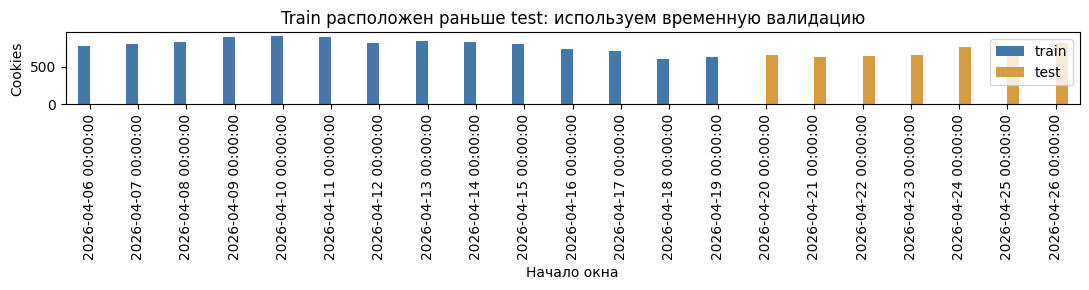

In [4]:
def select_events(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
                      on='cookie_id', how='inner', validate='many_to_one')
    return ev.loc[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)].sort_values(
        ['cookie_id', 'event_ts'], kind='stable').copy()

def normalize_platform(series):
    return series.str.lower().replace({'desktop': 'web', 'iphone': 'ios'}).fillna('unknown')

all_meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
joined = events.merge(all_meta, on='cookie_id', how='left', validate='many_to_one')
assert joined.window_start_ts.notna().all()
window_audit = pd.Series({
    'before_start': (joined.event_ts < joined.window_start_ts).sum(),
    'at_start': (joined.event_ts == joined.window_start_ts).sum(),
    'at_end': (joined.event_ts == joined.window_end_ts).sum(),
    'at_or_after_end': (joined.event_ts >= joined.window_end_ts).sum(),
    'before_cookie_creation': (joined.event_ts < joined.cookie_created_at).sum(),
}, name='events')
display(window_audit.to_frame())
window_events = {name: select_events(events, meta) for name, meta in [('train', train), ('test', test)]}
comparison = []
date_counts = []
platform_counts = []
for name, meta in [('train', train), ('test', test)]:
    ev = window_events[name]
    counts = ev.groupby('cookie_id').size().reindex(meta.cookie_id, fill_value=0)
    age = (meta.window_start_ts - meta.cookie_created_at).dt.total_seconds() / 86400
    comparison.append({'split': name, 'first_window': meta.window_start_ts.min(),
        'last_window': meta.window_start_ts.max(), 'events_in_window': len(ev),
        'cookies_without_events': int(counts.eq(0).sum()), 'events_mean': counts.mean(),
        'events_median': counts.median(), 'age_days_median': age.median()})
    date_counts.append(meta.groupby('window_start_ts').size().rename(name))
    platform_counts.append(normalize_platform(ev.platform).value_counts(normalize=True).rename(name))
display(pd.DataFrame(comparison).set_index('split'))
display(pd.concat(platform_counts, axis=1))
pd.concat(date_counts, axis=1).fillna(0).plot.bar(figsize=(11, 3), color=['#4677a9', '#d79b42'])
plt.ylabel('Cookies')
plt.xlabel('Начало окна')
plt.title('Train расположен раньше test: используем временную валидацию')
plt.tight_layout()
plt.show()
del joined, all_meta

40 779 событий лежат вне окна, в том числе 68 ровно на правой границе; они исключены.
Внутри окон остаётся 198 436 событий train и 89 690 test. Cookies без событий сейчас нет,
но сборка признаков сохраняет такие строки и проверяется на искусственном примере.
Медиана активности train/test одинакова — 12 событий; медиана возраста cookie — 59,76/58,63 дня.
Окна train относятся к 6–19 апреля, test — к 20–26 апреля, поэтому случайный split не используем.

## 4. Метрика

$$\max_{t:\;\mathrm{Recall}(t)\geq0.70}\mathrm{Precision}(t),\qquad
\widehat y_i=\mathbf{1}[s_i\geq t].$$

Порог перебирается по уникальным scores; одинаковые scores неделимы.
Precision может вырасти **после** первого порога, достигшего Recall=70%, поэтому нужен максимум
по всей допустимой области. AP и ROC-AUC сохраняем только для диагностики.
Порог ниже нужен для анализа ошибок на валидации; в submission его нет.

In [5]:
def evaluate(y, score):
    return {'precision_at_recall70': precision_at_recall(y, score),
            'average_precision': average_precision_score(y, score),
            'roc_auc': roc_auc_score(y, score)}

def operating_point(y, score):
    order = np.argsort(-score, kind='stable')
    s, y = np.asarray(score)[order], np.asarray(y)[order]
    ends = np.r_[s[1:] != s[:-1], True]
    tp = np.cumsum(y)[ends]
    k = np.arange(1, len(y) + 1)[ends]
    precision, recall = tp / k, tp / y.sum()
    allowed = np.flatnonzero(recall >= .7)
    i = allowed[np.argmax(precision[allowed])]
    return {'threshold': float(s[ends][i]), 'precision': float(precision[i]),
            'recall': float(recall[i]), 'tp': int(tp[i]), 'fp': int(k[i] - tp[i]),
            'fn': int(y.sum() - tp[i])}

assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
assert precision_at_recall([1, 1, 0, 0], [.5, .5, .5, .5]) == 0.5
assert precision_at_recall([0, 0, 1, 1], [.5, .5, .5, .5]) == 0.5
print('Метрика: максимум по допустимым порогам и обработка совпадающих scores проверены.')

Метрика: максимум по допустимым порогам и обработка совпадающих scores проверены.


## 5. Признаки

| Группа | Что считаем |
|---|---|
| Базовая | Число и доли действий, активные часы/минуты, длительность, паузы и их разброс, максимум событий за скользящие 60 секунд |
| Объявления и поиск — тоже базовые | Разнообразие объявлений, категорий, локаций, продавцов и запросов; повторы просмотров; средняя и максимальная страница поиска |
| Метаданные — базовые | Возраст cookie к началу окна, число платформ и User-Agent, основная нормализованная платформа |
| Последовательности | Одинаковые действия подряд, серии и разнообразие переходов |
| Дополнительный поиск | Повторы запросов, последовательное перелистывание одного запроса |
| Сессии | Новая сессия после паузы строго больше 30 минут; размеры и длительности |
| UA | Локальный разбор семейства браузера, ОС и типа устройства без номеров версий |
| Координаты | Доступность, уникальные позиции, повторы и разброс на web-событиях |

Отношения при нулевом знаменателе остаются NaN. Для отсутствующей активности счётчики — 0,
неопределённые статистики — NaN. `cookie_id` остаётся только индексом; `item_id` используется
в агрегатах, а не как отдельный признак. Группы с совпадающим временем не задают известного порядка,
поэтому исключаются из последовательных переходов.

Координаты — отдельные наблюдения, **не траектория мыши**. На мобильных платформах эти признаки
не вычисляются как координаты курсора; отсутствие координат не превращается в ручное правило «бот».

In [6]:
def parse_ua(ua):
    ua = str(ua).lower()
    browser = next((v for pattern, v in [
        ('headlesschrome', 'headless'), ('yabrowser', 'yandex'), ('edg', 'edge'),
        ('opr/', 'opera'), ('chrome', 'chrome'), ('firefox', 'firefox'),
        ('safari', 'safari'), ('okhttp', 'okhttp'), ('python', 'python'),
        ('curl', 'curl')] if pattern in ua), 'other')
    os_name = next((v for pattern, v in [('android', 'android'), ('iphone', 'ios'),
        ('ipad', 'ios'), ('windows', 'windows'), ('macintosh', 'macos'), ('linux', 'linux')]
        if pattern in ua), 'other')
    device = 'tablet' if 'ipad' in ua or ('android' in ua and 'mobile' not in ua) else (
        'mobile' if any(x in ua for x in ['mobile', 'iphone', 'android']) else 'desktop')
    return browser, os_name, device

def ratio(a, b):
    return a / b if b else np.nan

def entropy(values):
    _, counts = np.unique(values, return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())

In [7]:
def build_features(events, meta):
    ev = select_events(events, meta)
    ev['platform_norm'] = normalize_platform(ev.platform)
    # Parse each distinct string locally; versions and raw strings never enter the model.
    ua_map = {u: parse_ua(u) for u in ev.user_agent.fillna('').unique()}
    for i, col in enumerate(['browser', 'os', 'device']):
        ev[col] = ev.user_agent.fillna('').map({k: v[i] for k, v in ua_map.items()})
    rows = []
    for cookie, g in ev.groupby('cookie_id', sort=False):
        n = len(g)
        t = g.event_ts.to_numpy(dtype='datetime64[ns]').astype('int64') / 1e9
        dt = np.diff(t)
        e = g.eid.to_numpy()
        d = {'cookie_id': cookie, 'n_events': n, 'event_types': g.eid.nunique(),
             'active_seconds': t[-1] - t[0], 'active_hours': g.event_ts.dt.floor('h').nunique(),
             'active_minutes': g.event_ts.dt.floor('min').nunique(),
             'max_events_minute': g.event_ts.dt.floor('min').value_counts().max(),
             'night_share': g.event_ts.dt.hour.lt(6).mean(),
             'first_offset_seconds': (g.event_ts.iloc[0] - g.window_start_ts.iloc[0]).total_seconds(),
             'last_recency_seconds': (g.window_end_ts.iloc[0] - g.event_ts.iloc[-1]).total_seconds(),
             'platform_nunique': g.platform_norm.nunique(), 'user_agent_nunique': g.user_agent.nunique(),
             'platform_mode': g.platform_norm.mode().iloc[0]}
        # True sliding 60-second window, not just aligned minute bins.
        d['max_events_60seconds'] = int(np.max(np.arange(n) - np.searchsorted(t, t - 60, side='right') + 1))
        for name, fn in [('mean', np.mean), ('median', np.median), ('std', np.std),
                         ('min', np.min), ('max', np.max)]:
            d[f'gap_{name}'] = float(fn(dt)) if len(dt) else np.nan
        d['gap_iqr'] = float(np.quantile(dt, .75) - np.quantile(dt, .25)) if len(dt) else np.nan
        d['gap_cv'] = ratio(d['gap_std'], d['gap_mean'])
        for threshold in [0, 1, 5, 30, 60]:
            d[f'gap_le_{threshold}_share'] = float((dt <= threshold).mean()) if len(dt) else np.nan
        for eid, name in EVENTS.items():
            d[f'count_{name}'] = int((e == eid).sum())
            d[f'share_{name}'] = d[f'count_{name}'] / n
        d['count_contact'] = int(np.isin(e, [300, 301, 303]).sum())
        d['share_contact'] = d['count_contact'] / n
        for col in ['item_id', 'item_category', 'item_location', 'seller_type', 'search_query']:
            d[f'{col}_nunique'] = g[col].nunique()
            d[f'{col}_unique_share'] = ratio(g[col].nunique(), g[col].notna().sum())
        views = g.loc[g.eid.eq(200), 'item_id'].dropna()
        d['item_repeat_share'] = 1 - ratio(views.nunique(), len(views))
        d['search_page_max'] = g.search_page.max()
        d['search_page_mean'] = g.search_page.mean()
        d['events_per_active_minute'] = n / d['active_minutes']
        # The event order within equal timestamps is unknown: exclude such blocks
        # and their edges from ordered transitions rather than imposing an order.
        unambiguous = ~g.event_ts.duplicated(keep=False).to_numpy()
        pair_ok = unambiguous[:-1] & unambiguous[1:]
        same = (e[1:] == e[:-1]) & pair_ok
        d['sequence_same_action_share'] = ratio(same.sum(), pair_ok.sum())
        runs = np.diff(np.r_[0, np.flatnonzero(~same) + 1, n])
        d['sequence_max_run'] = runs.max()
        transitions = np.array([f'{a}>{b}' for a, b in zip(e[:-1][pair_ok], e[1:][pair_ok])])
        d['sequence_transition_nunique'] = len(np.unique(transitions))
        d['sequence_transition_entropy'] = entropy(transitions) if len(transitions) else np.nan
        d['sequence_event_entropy'] = entropy(e)
        search = g[g.eid.eq(100)]
        queries = search.search_query.dropna().astype(str).str.strip().str.lower()
        d['search_repeat_share'] = 1 - ratio(queries.nunique(), len(queries))
        d['search_query_entropy'] = entropy(queries) if len(queries) else np.nan
        ds = search.search_page.diff()
        valid_search_pair = (~search.event_ts.duplicated(keep=False)) & (~search.event_ts.duplicated(keep=False)).shift(fill_value=False)
        same_query = search.search_query.eq(search.search_query.shift()) & search.search_query.notna()
        ok = ds.notna() & valid_search_pair & same_query
        d['search_next_page_share'] = ratio((ds.eq(1) & ok).sum(), ok.sum())
        d['search_same_page_share'] = ratio((ds.eq(0) & ok).sum(), ok.sum())
        # New session after strictly more than 30 minutes without activity.
        starts = np.r_[0, np.flatnonzero(dt > 1800) + 1]
        ends = np.r_[starts[1:] - 1, n - 1]
        sizes, durations = ends - starts + 1, t[ends] - t[starts]
        d['sessions_count'] = len(starts)
        for name, fn in [('mean', np.mean), ('max', np.max), ('median', np.median)]:
            d[f'sessions_size_{name}'] = fn(sizes)
            d[f'sessions_duration_{name}'] = fn(durations)
        for col in ['browser', 'os', 'device']:
            d[f'ua_{col}_mode'] = g[col].mode().iloc[0]
            d[f'ua_{col}_nunique'] = g[col].nunique()
        d['ua_headless_share'] = g.browser.eq('headless').mean()
        # Coordinates are snapshots, only on web events; never a trajectory.
        eligible = g[g.platform_norm.eq('web')]
        coords = eligible[['pointer_x', 'pointer_y']].dropna()
        d['pointer_observed_count'] = len(coords)
        d['pointer_available_share'] = ratio(len(coords), len(eligible))
        d['pointer_unique_count'] = len(coords.drop_duplicates())
        d['pointer_repeat_share'] = 1 - ratio(d['pointer_unique_count'], len(coords))
        for col in ['pointer_x', 'pointer_y']:
            d[f'pointer_{col}_std'] = coords[col].std() if len(coords) > 1 else np.nan
        rows.append(d)
    f = pd.DataFrame(rows).set_index('cookie_id').reindex(meta.cookie_id)
    f.index.name = 'cookie_id'
    counts = [c for c in f if c.startswith('count_') or c.endswith('_nunique')]
    counts += ['n_events', 'event_types', 'active_hours', 'active_minutes', 'max_events_minute',
               'max_events_60seconds', 'sequence_max_run', 'sessions_count',
               'pointer_observed_count', 'pointer_unique_count']
    f[counts] = f[counts].fillna(0)
    f['cookie_age_start_days'] = ((meta.window_start_ts - meta.cookie_created_at).dt.total_seconds() / 86400).to_numpy()
    f['window_seconds'] = (meta.window_end_ts - meta.window_start_ts).dt.total_seconds().to_numpy()
    for c in f.select_dtypes(include='object'):
        f[c] = f[c].fillna('unknown')
    f = f.replace([np.inf, -np.inf], np.nan)
    assert f.index.is_unique and len(f) == len(meta)
    groups = {group: [c for c in f if c.startswith(group + '_')] for group in EXTRA_GROUPS}
    # Basic query diversity/page statistics belong to the first feature version.
    # Only repetition and ordered pagination are part of the search ablation.
    groups['search'] = ['search_repeat_share', 'search_query_entropy',
                        'search_next_page_share', 'search_same_page_share']
    groups['base'] = [c for c in f if not any(c in cols for cols in groups.values())]
    return f, groups

### Проверки до обучения

На небольших искусственных данных проверяем левую/правую границы окна, сортировку,
сохранение cookies без событий, неделимость совпадающих scores и формат submission.
Отдельно меняем данные **за пределами окна** и убеждаемся, что признаки не меняются.
Эти cookies искусственные и не задают ответы ни одной реальной тестовой cookie.

In [8]:
def validate_submission(sub, test, sample):
    assert list(sub.columns) == ['cookie_id', 'score']
    assert len(sub) == len(test) == len(sample)
    assert sub.cookie_id.notna().all() and sub.cookie_id.is_unique
    assert set(sub.cookie_id) == set(test.cookie_id) == set(sample.cookie_id)
    assert sub.cookie_id.tolist() == sample.cookie_id.tolist()
    assert np.isfinite(sub.score).all() and sub.score.between(0, 1).all()

In [9]:
class MetricTests(unittest.TestCase):
    def test_later_threshold_can_improve_precision(self):
        self.assertEqual(precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]), .8)

    def test_ties_are_indivisible(self):
        self.assertEqual(precision_at_recall([1, 1, 0, 0], [.5] * 4), .5)
        self.assertEqual(precision_at_recall([0, 0, 1, 1], [.5] * 4), .5)

    def test_matches_brute_force_unique_thresholds(self):
        rng = np.random.default_rng(12)
        for _ in range(100):
            y = rng.integers(0, 2, 25)
            s = rng.integers(0, 5, 25) / 4
            expected = max(y[s >= t].mean() for t in np.unique(s) if y[s >= t].sum() / y.sum() >= .7)
            self.assertAlmostEqual(precision_at_recall(y, s), expected)
            op = operating_point(y, s)
            self.assertAlmostEqual(op['precision'], expected)
            self.assertGreaterEqual(op['recall'], .7)

class FeatureTests(unittest.TestCase):
    def setUp(self):
        self.meta = pd.DataFrame({'cookie_id': ['a', 'b', 'empty'],
            'cookie_created_at': pd.to_datetime(['2026-03-01'] * 3),
            'window_start_ts': pd.to_datetime(['2026-04-06'] * 3),
            'window_end_ts': pd.to_datetime(['2026-04-07'] * 3)})
        self.events = pd.DataFrame({
            'cookie_id': ['a', 'a', 'a', 'a', 'b'],
            'event_ts': pd.to_datetime(['2026-04-07', '2026-04-06 00:00:10',
                '2026-04-05 23:59:59', '2026-04-06', '2026-04-06'], format='mixed'),
            'eid': [900, 200, 900, 200, 200], 'event_name': ['captcha_shown', 'item_view', 'captcha_shown', 'item_view', 'item_view'],
            'platform': ['WEB'] * 5, 'user_agent': ['Chrome/123 Windows'] * 5,
            'item_id': [999, 1, 999, 1, 2], 'item_category': ['cat'] * 5,
            'item_location': ['city'] * 5, 'seller_type': ['private'] * 5,
            'search_query': [np.nan] * 5, 'search_page': [np.nan] * 5,
            'pointer_x': [np.nan] * 5, 'pointer_y': [np.nan] * 5})

    def test_window_sorting_empty_cookie_and_undefined_statistics(self):
        f, groups = build_features(self.events, self.meta)
        self.assertEqual(f.index.tolist(), self.meta.cookie_id.tolist())
        self.assertEqual(f.loc['a', 'n_events'], 2)
        self.assertEqual(f.loc['a', 'gap_mean'], 10)
        self.assertEqual(f.loc['a', 'count_captcha_shown'], 0)
        self.assertEqual(f.loc['empty', 'n_events'], 0)
        self.assertEqual(f.loc['empty', 'item_id_nunique'], 0)
        self.assertTrue(np.isnan(f.loc['empty', 'gap_mean']))
        self.assertTrue(np.isnan(f.loc['b', 'gap_mean']))
        self.assertNotIn('cookie_id', f.columns)
        self.assertIn('search_page_max', groups['base'])
        self.assertIn('search_query_nunique', groups['base'])
        self.assertNotIn('search_repeat_share', groups['base'])

    def test_outside_window_values_cannot_change_features(self):
        f, _ = build_features(self.events, self.meta)
        changed = self.events.copy()
        changed.loc[[0, 2], 'item_id'] = 123456
        changed.loc[[0, 2], 'user_agent'] = 'headlesschrome'
        changed.loc[[0, 2], 'pointer_x'] = 99999
        f2, _ = build_features(changed, self.meta)
        pd.testing.assert_frame_equal(f, f2)

    def test_exact_duplicates_preserved(self):
        selected = select_events(self.events, self.meta)
        duplicated = pd.concat([self.events, selected.drop(columns=['window_start_ts', 'window_end_ts'])])
        f, _ = build_features(duplicated, self.meta)
        self.assertEqual(f.loc['a', 'n_events'], 4)
        self.assertTrue(np.isnan(f.loc['a', 'sequence_same_action_share']))

class SubmissionTests(unittest.TestCase):
    def test_reject_invalid_submission(self):
        sample = pd.DataFrame({'cookie_id': ['a', 'b'], 'score': [.1, .2]})
        validate_submission(sample, sample[['cookie_id']], sample)
        for values in [[np.nan, .2], [np.inf, .2], [-.1, .2], [1.1, .2]]:
            with self.assertRaises(AssertionError):
                validate_submission(sample.assign(score=values), sample[['cookie_id']], sample)
        with self.assertRaises(AssertionError):
            validate_submission(sample.assign(cookie_id=['a', 'a']), sample[['cookie_id']], sample)

suite = unittest.TestSuite()
for case in [MetricTests, FeatureTests, SubmissionTests]:
    suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(case))
test_result = unittest.TextTestRunner(verbosity=1).run(suite)
assert test_result.wasSuccessful()

.......
----------------------------------------------------------------------
Ran 7 tests in 0.183s

OK


In [10]:
print('Собираем признаки train из исходных событий...')
x, groups = build_features(events, train)
y = train.target.to_numpy()
assert x.index.tolist() == train.cookie_id.tolist()
assert 'cookie_id' not in x.columns and 'target' not in x.columns
assert 'search_page_max' in groups['base'] and 'search_query_nunique' in groups['base']
display(pd.Series({name: len(cols) for name, cols in groups.items()}, name='features').to_frame())
display(x.head())

Собираем признаки train из исходных событий...


,features
sequence,5
search,4
sessions,7
ua,7
pointer,6
base,63


,n_events,event_types,active_seconds,active_hours,active_minutes,max_events_minute,night_share,first_offset_seconds,...,pointer_observed_count,pointer_available_share,pointer_unique_count,pointer_repeat_share,pointer_pointer_x_std,pointer_pointer_y_std,cookie_age_start_days,window_seconds
cookie_id,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,7,3,167.0,1,4,2,1.00000,5487.0,...,0,NaN,0,NaN,NaN,NaN,135.603692,86400.0
ck_7e4de46eeab82974,41,7,39476.0,8,30,3,0.00000,39026.0,...,38,0.926829,38,0.000000,509.231969,272.953569,194.576111,86400.0
ck_9320229ef6304522,36,9,36491.0,7,21,4,0.50000,4254.0,...,35,0.972222,35,0.000000,602.124295,312.027426,32.994421,86400.0
ck_30ccd25bc1714ed9,21,5,17221.0,3,16,2,0.52381,8850.0,...,0,0.000000,0,NaN,NaN,NaN,0.546759,86400.0
ck_a77c5f05948cdeef,29,6,19098.0,5,25,2,0.00000,29279.0,...,28,0.965517,27,0.035714,450.787816,297.263925,94.837095,86400.0


## 6. Временная валидация

Два последовательных фолда с расширяющимся обучением: 6–13 → 14–16 апреля и
6–16 → 17–19 апреля. Второй точно соответствует quickstart. Окна обучения заканчиваются
не позже начала валидации. В каждой части есть оба класса, cookies не пересекаются.

**Ограничение:** оба фолда используются для выбора модели и early stopping.
Метрики ниже — локальные оценки при подборе, не результат независимого финального holdout.

In [11]:
FOLDS = [('earlier', '2026-04-14', '2026-04-17'), ('latest', '2026-04-17', '2026-04-20')]
folds = []
for name, start, end in FOLDS:
    fit = np.flatnonzero((train.window_start_ts < start) & (train.window_end_ts <= start))
    valid = np.flatnonzero((train.window_start_ts >= start) & (train.window_start_ts < end))
    assert len(fit) and len(valid)
    assert not (set(train.cookie_id.iloc[fit]) & set(train.cookie_id.iloc[valid]))
    assert train.window_end_ts.iloc[fit].max() <= train.window_start_ts.iloc[valid].min()
    assert len(np.unique(y[fit])) == len(np.unique(y[valid])) == 2
    folds.append((name, fit, valid))
latest = folds[-1][2]
display(pd.DataFrame([{'fold': name, 'train_n': len(fit), 'valid_n': len(valid),
    'train_positive': int(y[fit].sum()), 'valid_positive': int(y[valid].sum()),
    'train_last_end': train.window_end_ts.iloc[fit].max(),
    'valid_first_start': train.window_start_ts.iloc[valid].min()}
    for name, fit, valid in folds]))

,fold,train_n,valid_n,train_positive,valid_positive,train_last_end,valid_first_start
0,earlier,6773,2367,544,195,2026-04-14,2026-04-14
1,latest,9140,1951,739,160,2026-04-17,2026-04-17


## 7. Quickstart и понятные baseline-модели

- **Quickstart:** RandomForest, 300 деревьев, min_samples_leaf=3, seed=0; только число событий и уникальных объявлений.
- **Логистическая регрессия:** медианная импутация и индикаторы пропусков, signed-log1p, масштабирование;
  one-hot для платформы, C=1. Преобразования обучаются только на обучающей части фолда.
- **CatBoost:** глубина 5, learning_rate=0,04, L2=5, максимум 1000 деревьев.
  Early stopping по Logloss с patience=100. Модели сравниваем по целевой метрике, а не Logloss.

CatBoost получает числовые пропуски как -999, категориальные — `unknown`.
Веса классов по умолчанию не включаем; Balanced проверим отдельным экспериментом.

In [12]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def prepare_cat(x):
    x = x.copy()
    for c in x.select_dtypes(include='number'):
        x[c] = x[c].fillna(-999.0)
    return x

def fit_predict(config, x, y, fit, valid):
    start = time.monotonic()
    if config['kind'] == 'rf':
        model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=4)
        model.fit(x.iloc[fit], y[fit])
        iterations = 300
    elif config['kind'] == 'lr':
        cat = list(x.select_dtypes(include='object').columns)
        num = [c for c in x if c not in cat]
        prep = ColumnTransformer([
            ('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True)),
                              ('log', FunctionTransformer(signed_log1p)), ('scale', StandardScaler())]), num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat)])
        model = Pipeline([('preprocess', prep), ('model', LogisticRegression(
            C=config.get('C', 1.), max_iter=3000, random_state=SEED))])
        model.fit(x.iloc[fit], y[fit])
        iterations = int(model[-1].n_iter_.max())
    else:
        x = prepare_cat(x)
        model = CatBoostClassifier(iterations=1000, depth=config.get('depth', 5), learning_rate=.04,
            l2_leaf_reg=5, loss_function='Logloss', eval_metric='Logloss', random_seed=SEED,
            thread_count=4, allow_writing_files=False, verbose=False,
            auto_class_weights='Balanced' if config.get('balanced') else None,
            cat_features=list(x.select_dtypes(include='object').columns))
        model.fit(x.iloc[fit], y[fit], eval_set=(x.iloc[valid], y[valid]),
                  early_stopping_rounds=100, use_best_model=True)
        iterations = model.tree_count_
    pred = model.predict_proba(x.iloc[valid])[:, 1]
    return model, pred, iterations, time.monotonic() - start

In [13]:
configs, results, models, predictions = {}, [], {}, {}

def experiment(name, kind='cat', extra=(), **params):
    config = {'kind': kind, 'groups': ['base', *extra], **params}
    cols = ['n_events', 'item_id_nunique'] if kind == 'rf' else [c for g in config['groups'] for c in groups[g]]
    config['columns'] = cols
    configs[name] = config
    for fold, fit, valid in folds:
        model, pred, iterations, seconds = fit_predict(config, x[cols], y, fit, valid)
        result = {'experiment': name, 'fold': fold, 'features': len(cols), 'iterations': iterations,
                  'seconds': seconds, 'parameters': json.dumps({k: v for k, v in config.items() if k != 'columns'}),
                  **evaluate(y[valid], pred)}
        results.append(result)
        models[name, fold] = model
        predictions[name, fold] = pred
        print(name, fold, {k: round(v, 5) for k, v in evaluate(y[valid], pred).items()},
              'iterations', iterations, flush=True)

experiment('quickstart', kind='rf')
experiment('logistic', kind='lr')
experiment('cat_base')
display(pd.DataFrame(results)[['experiment', 'fold', 'features', 'iterations',
    'precision_at_recall70', 'average_precision', 'roc_auc']])

quickstart earlier {'precision_at_recall70': 0.10468, 'average_precision': 0.2352, 'roc_auc': 0.63745} iterations 300
quickstart latest {'precision_at_recall70': 0.10247, 'average_precision': 0.17461, 'roc_auc': 0.6074} iterations 300
logistic earlier {'precision_at_recall70': 0.41018, 'average_precision': 0.65888, 'roc_auc': 0.88292} iterations 85
logistic latest {'precision_at_recall70': 0.42586, 'average_precision': 0.62678, 'roc_auc': 0.88326} iterations 87
cat_base earlier {'precision_at_recall70': 0.53937, 'average_precision': 0.74321, 'roc_auc': 0.92632} iterations 620
cat_base latest {'precision_at_recall70': 0.54106, 'average_precision': 0.7169, 'roc_auc': 0.90226} iterations 750


,experiment,fold,features,iterations,precision_at_recall70,average_precision,roc_auc
0,quickstart,earlier,2,300,0.104677,0.235197,0.637447
1,quickstart,latest,2,300,0.102470,0.174609,0.607396
2,logistic,earlier,63,85,0.410180,0.658877,0.882918
3,logistic,latest,63,87,0.425856,0.626779,0.883264
4,cat_base,earlier,63,620,0.539370,0.743205,0.926319
5,cat_base,latest,63,750,0.541063,0.716895,0.902265


### Проверка совпадения с исходным quickstart

Независимо повторяем его двухпризнаковую агрегацию и RandomForest на том же разбиении.
Сравниваем не только метрику, но и весь вектор оценок. Исходный baseline после обучения на всём train
оставляем в памяти как `quickstart_submission`, чтобы не создавать ещё один CSV.

In [14]:
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({'n_events': g.size(), 'item_nunique': g.item_id.nunique()})
    return meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left').fillna(0)

basic_train = basic_features(window_events['train'], train)
basic_test = basic_features(window_events['test'], test)
is_valid = train.window_start_ts.ge('2026-04-17').to_numpy()
qs_cols = ['n_events', 'item_nunique']
qs_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
qs_model.fit(basic_train.loc[~is_valid, qs_cols], y[~is_valid])
qs_scores = qs_model.predict_proba(basic_train.loc[is_valid, qs_cols])[:, 1]
np.testing.assert_allclose(qs_scores, predictions['quickstart', 'latest'], atol=1e-14, rtol=0)
print('Quickstart на позднем фолде:', evaluate(y[is_valid], qs_scores))
qs_model.fit(basic_train[qs_cols], y)
quickstart_submission = sample[['cookie_id']].merge(pd.DataFrame({
    'cookie_id': test.cookie_id, 'score': qs_model.predict_proba(basic_test[qs_cols])[:, 1]}),
    on='cookie_id', how='left', validate='one_to_one', sort=False)
validate_submission(quickstart_submission, test, sample)
display(quickstart_submission.head())

Quickstart на позднем фолде: {'precision_at_recall70': 0.10247026532479414, 'average_precision': 0.1746089870059772, 'roc_auc': 0.6073963567839197}


,cookie_id,score
0,ck_99a4e5ef02d89493,0.017452
1,ck_54d463f7fd89ec3d,0.052262
2,ck_0fbbc7a6af300368,0.025094
3,ck_8fd4937eadd64fb6,0.000588
4,ck_dbb4bd4eda97255d,0.156108


## 8. Ошибки baseline и отдельные группы признаков

Сначала посмотрим ложные срабатывания и пропущенных ботов при рабочем Recall ≥ 70%.
Далее каждую дополнительную группу добавляем **отдельно** к одной и той же базе.
Правило допуска к объединённому варианту фиксируем заранее: средняя метрика должна вырасти,
а падение на любом отдельном фолде не должно превышать 0,01.

In [15]:
def diagnostic_tables(name, meta, x, y, score):
    op = operating_point(y, score)
    pred = score >= op['threshold']
    data = pd.DataFrame({'cookie_id': meta.cookie_id.to_numpy(), 'target': y, 'score': score,
                         'predicted': pred, 'platform': x.platform_mode.to_numpy(),
                         'activity': pd.cut(x.n_events, [-1, 5, 15, 30, np.inf], labels=['0-5','6-15','16-30','31+']).astype(str).to_numpy(),
                         'age': pd.cut(x.cookie_age_start_days, [-np.inf, 1, 7, 30, 180, np.inf],
                                      labels=['<=1d','1-7d','7-30d','30-180d','>180d']).astype(str).to_numpy()})
    slices = []
    for field in ['platform', 'activity', 'age']:
        for value, g in data.groupby(field, observed=True):
            tp = ((g.target == 1) & g.predicted).sum()
            fp = ((g.target == 0) & g.predicted).sum()
            slices.append({'slice': field, 'value': value, 'n': len(g), 'positives': int(g.target.sum()),
                'tp': tp, 'fp': fp, 'fn': int(g.target.sum() - tp),
                'precision_at_global_threshold': tp / (tp + fp) if tp + fp else np.nan,
                'recall_at_global_threshold': tp / g.target.sum() if g.target.sum() else np.nan})
    slice_table = pd.DataFrame(slices)
    errors = data.loc[data.target.ne(data.predicted.astype(int))].merge(x.reset_index(), on='cookie_id')



    # A fixed threshold is used across slices; it is never sent with the submission.
    return op, slice_table, errors, data

base_op, base_slices, base_errors, _ = diagnostic_tables(
    'baseline', train.iloc[latest], x.iloc[latest], y[latest], predictions['cat_base', 'latest'])
display(pd.Series(base_op, name='baseline').to_frame())
display(base_errors.groupby('target')[['n_events', 'gap_mean', 'item_id_unique_share',
    'cookie_age_start_days']].median())

,baseline
threshold,0.136568
precision,0.541063
recall,0.700000
tp,112.000000
fp,95.000000
fn,48.000000


,n_events,gap_mean,item_id_unique_share,cookie_age_start_days
target,,,,
0,19.0,400.000000,0.800000,29.685602
1,13.0,816.809524,0.820043,42.285087


Разнообразие и интервалы уже помогают baseline, но у более медленных и малоактивных ботов мало
наблюдений. Проверяем, добавляют ли информацию повторяемость действий, поиск, сессии, UA и координаты.
Не задаём отдельных правил для конкретных cookies; все сравнения относятся только к размеченному train.

In [16]:
for group in EXTRA_GROUPS:
    experiment('cat_' + group, extra=[group])
scores = pd.DataFrame(results).pivot(index='experiment', columns='fold', values='precision_at_recall70')
kept = [g for g in EXTRA_GROUPS if scores.loc['cat_' + g].mean() > scores.loc['cat_base'].mean()
        and (scores.loc['cat_' + g] >= scores.loc['cat_base'] - .01).all()]
display(scores)
print('Группы, допущенные к объединению:', kept)

cat_sequence earlier {'precision_at_recall70': 0.57083, 'average_precision': 0.74021, 'roc_auc': 0.9247} iterations 654
cat_sequence latest {'precision_at_recall70': 0.48069, 'average_precision': 0.7082, 'roc_auc': 0.90373} iterations 455
cat_search earlier {'precision_at_recall70': 0.53516, 'average_precision': 0.73633, 'roc_auc': 0.92301} iterations 581
cat_search latest {'precision_at_recall70': 0.57143, 'average_precision': 0.7122, 'roc_auc': 0.89985} iterations 564
cat_sessions earlier {'precision_at_recall70': 0.4964, 'average_precision': 0.73525, 'roc_auc': 0.92622} iterations 612
cat_sessions latest {'precision_at_recall70': 0.58639, 'average_precision': 0.71123, 'roc_auc': 0.90467} iterations 406
cat_ua earlier {'precision_at_recall70': 0.56379, 'average_precision': 0.73738, 'roc_auc': 0.92291} iterations 708
cat_ua latest {'precision_at_recall70': 0.54902, 'average_precision': 0.71604, 'roc_auc': 0.90318} iterations 362
cat_pointer earlier {'precision_at_recall70': 0.72251, '

fold,earlier,latest
experiment,,
cat_base,0.539370,0.541063
cat_pointer,0.722513,0.741722
cat_search,0.535156,0.571429
cat_sequence,0.570833,0.480687
cat_sessions,0.496403,0.586387
cat_ua,0.563786,0.549020
logistic,0.410180,0.425856
quickstart,0.104677,0.102470


Проверяем объединение прошедших групп, меньшую глубину и Balanced.
Это небольшой заранее ограниченный набор экспериментов; по скрытому test параметры не подбираются.
Из допустимых моделей выбираем максимальное среднее основной метрики на двух фолдах;
при равенстве — наибольшее минимальное значение.

cat_combined earlier {'precision_at_recall70': 0.72251, 'average_precision': 0.78954, 'roc_auc': 0.94217} iterations 750
cat_combined latest {'precision_at_recall70': 0.73203, 'average_precision': 0.77092, 'roc_auc': 0.92931} iterations 302
cat_depth4 earlier {'precision_at_recall70': 0.70984, 'average_precision': 0.79055, 'roc_auc': 0.94343} iterations 968
cat_depth4 latest {'precision_at_recall70': 0.72258, 'average_precision': 0.76949, 'roc_auc': 0.93065} iterations 818
cat_balanced earlier {'precision_at_recall70': 0.68844, 'average_precision': 0.77739, 'roc_auc': 0.94157} iterations 257
cat_balanced latest {'precision_at_recall70': 0.65116, 'average_precision': 0.7349, 'roc_auc': 0.93066} iterations 227
Выбрана модель: cat_pointer | группы: ['base', 'pointer']


fold,earlier,latest
experiment,,
cat_balanced,0.688442,0.651163
cat_base,0.539370,0.541063
cat_combined,0.722513,0.732026
cat_depth4,0.709845,0.722581
cat_pointer,0.722513,0.741722
cat_search,0.535156,0.571429
cat_sequence,0.570833,0.480687
cat_sessions,0.496403,0.586387
cat_ua,0.563786,0.549020


fold,earlier,latest,mean,minimum
experiment,,,,
cat_pointer,0.722513,0.741722,0.732117,0.722513
cat_combined,0.722513,0.732026,0.727270,0.722513
cat_depth4,0.709845,0.722581,0.716213,0.709845
cat_balanced,0.688442,0.651163,0.669803,0.651163
cat_ua,0.563786,0.549020,0.556403,0.549020
cat_search,0.535156,0.571429,0.553292,0.535156
cat_base,0.539370,0.541063,0.540216,0.539370
logistic,0.410180,0.425856,0.418018,0.410180
quickstart,0.104677,0.102470,0.103574,0.102470


,experiment,fold,features,iterations,precision_at_recall70,average_precision,roc_auc,parameters
0,quickstart,earlier,2,300,0.104677,0.235197,0.637447,"{""kind"": ""rf"", ""groups"": [""base""]}"
1,quickstart,latest,2,300,0.102470,0.174609,0.607396,"{""kind"": ""rf"", ""groups"": [""base""]}"
2,logistic,earlier,63,85,0.410180,0.658877,0.882918,"{""kind"": ""lr"", ""groups"": [""base""]}"
3,logistic,latest,63,87,0.425856,0.626779,0.883264,"{""kind"": ""lr"", ""groups"": [""base""]}"
4,cat_base,earlier,63,620,0.539370,0.743205,0.926319,"{""kind"": ""cat"", ""groups"": [""base""]}"
5,cat_base,latest,63,750,0.541063,0.716895,0.902265,"{""kind"": ""cat"", ""groups"": [""base""]}"
6,cat_sequence,earlier,68,654,0.570833,0.740214,0.924704,"{""kind"": ""cat"", ""groups"": [""base"", ""sequence""]}"
7,cat_sequence,latest,68,455,0.480687,0.708197,0.903727,"{""kind"": ""cat"", ""groups"": [""base"", ""sequence""]}"
8,cat_search,earlier,67,581,0.535156,0.736331,0.923013,"{""kind"": ""cat"", ""groups"": [""base"", ""search""]}"
9,cat_search,latest,67,564,0.571429,0.712204,0.899846,"{""kind"": ""cat"", ""groups"": [""base"", ""search""]}"


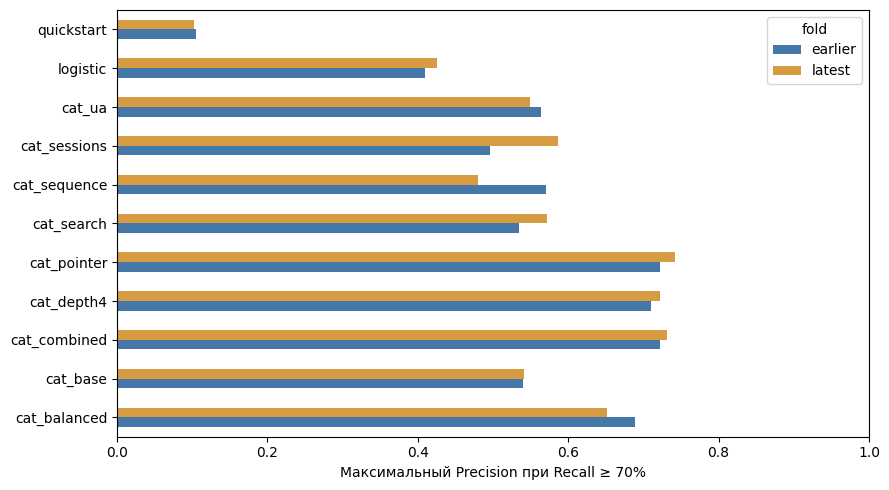

In [17]:
if kept:
    experiment('cat_combined', extra=kept)
experiment('cat_depth4', extra=kept, depth=4)
experiment('cat_balanced', extra=kept, balanced=True)
experiments = pd.DataFrame(results)
scores = experiments.pivot(index='experiment', columns='fold', values='precision_at_recall70')
eligible = [name for name, cfg in configs.items() if set(cfg['groups']) - {'base'} <= set(kept)]
ranking = scores.loc[eligible].assign(mean=scores.loc[eligible].mean(axis=1),
    minimum=scores.loc[eligible].min(axis=1)).sort_values(['mean', 'minimum'], ascending=False, kind='stable')
best = ranking.index[0]
config = configs[best]
display(scores)
display(ranking)
display(experiments[['experiment', 'fold', 'features', 'iterations', 'precision_at_recall70',
                     'average_precision', 'roc_auc', 'parameters']])
print('Выбрана модель:', best, '| группы:', config['groups'])
ax = scores.plot.barh(figsize=(9, 5), color=['#4677a9', '#d79b42'])
ax.set_xlabel('Максимальный Precision при Recall ≥ 70%')
ax.set_ylabel('')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

**Результат на предоставленных данных:** победил CatBoost «база + координаты», 69 признаков.
Precision по фолдам — **0,7225 / 0,7417**, среднее **0,7321**.
Quickstart на позднем фолде — 0,1025, логистическая регрессия — 0,4259.

Поиск, UA и координаты прошли критерий допуска к объединению, но их объединение уступило
более простой модели. Последовательности и сессии не дали устойчивого улучшения.
Веса Balanced также не помогли. Это результаты текущих входов; при замене данных ориентируемся
на вычисленные таблицы, а не на заранее записанные числа.

## 9. Ошибки, перенос порога и проверки сильных признаков

Для срезов используется **один общий порог**, выбранный на всём позднем фолде.
Нельзя выбирать отдельный удобный порог для каждой платформы и выдавать это за качество общей модели.
Идентификаторов сервисов во входах нет; перенос на сервис, отсутствующий в обучении, проверить нельзя.

In [18]:
op, slices, errors, valid_predictions = diagnostic_tables(
    'best', train.iloc[latest], x.iloc[latest], y[latest], predictions[best, 'latest'])
display(pd.Series(op, name='latest_fold').to_frame())
display(slices)
profiles = valid_predictions.merge(x.reset_index(), on='cookie_id', validate='one_to_one')
profiles['outcome'] = ['TP' if y_i and p else 'FN' if y_i else 'FP' if p else 'TN'
                      for y_i, p in zip(profiles.target, profiles.predicted)]
profile_cols = ['n_events', 'gap_mean', 'gap_cv', 'item_id_unique_share',
                'search_page_max', 'cookie_age_start_days', 'pointer_available_share']
profile_summary = profiles.groupby('outcome')[profile_cols].median()
profile_summary.insert(0, 'cookies', profiles.groupby('outcome').size())
display(profile_summary)
display(errors[['cookie_id', 'target', 'score', 'n_events', 'gap_mean']].head(10))

,latest_fold
threshold,0.237453
precision,0.741722
recall,0.700000
tp,112.000000
fp,39.000000
fn,48.000000


,slice,value,n,positives,tp,fp,fn,precision_at_global_threshold,recall_at_global_threshold
0,platform,android,800,54,33,16,21,0.673469,0.611111
1,platform,ios,107,4,2,3,2,0.400000,0.500000
2,platform,web,1044,102,77,20,25,0.793814,0.754902
3,activity,0-5,387,14,5,1,9,0.833333,0.357143
4,activity,16-30,498,55,42,18,13,0.700000,0.763636
5,activity,31+,322,46,38,10,8,0.791667,0.826087
6,activity,6-15,744,45,27,10,18,0.729730,0.600000
7,age,1-7d,247,34,28,9,6,0.756757,0.823529
8,age,30-180d,1159,61,34,14,27,0.708333,0.557377
9,age,7-30d,174,7,4,3,3,0.571429,0.571429


,cookies,n_events,gap_mean,gap_cv,item_id_unique_share,search_page_max,cookie_age_start_days,pointer_available_share
outcome,,,,,,,,
FN,48,13.5,757.500000,1.946963,0.820043,4.0,41.865851,0.785714
FP,39,19.0,350.000000,2.846000,0.800000,8.0,2.437998,0.000000
TN,1752,12.0,640.272727,1.909887,0.800000,4.0,60.524219,0.933333
TP,112,22.0,383.708333,2.657555,0.788676,7.0,1.956372,0.000000


,cookie_id,target,score,n_events,gap_mean
0,ck_abcb33d9e334de90,0,0.348015,24,412.826087
1,ck_bcb82e74605026e0,1,0.046136,7,906.833333
2,ck_1447749fdc45c5a7,1,0.221280,17,444.250000
3,ck_7713cde5002edefa,0,0.507108,43,152.238095
4,ck_df3469823ebd7e37,0,0.244041,28,975.000000
5,ck_c01626b3a0357a14,0,0.505572,18,220.058824
6,ck_02198cac9e1cc48a,1,0.012577,2,17.000000
7,ck_f924c1d7c7f1fd1c,0,0.237553,43,416.714286
8,ck_10dfe45c60292599,1,0.037624,17,1535.750000
9,ck_79e6d356c98cd4e8,1,0.008018,5,2840.000000


На позднем фолде TP=112, FP=39, FN=48 при Recall=0,70; AP=0,7611, ROC-AUC=0,9277.
Recall на web — 0,755, Android — 0,611, iOS — 0,50 (в iOS всего 4 положительных примера).
Для cookies с 0–5 событиями Recall=0,357, для 31+ события — 0,826.
Среди пропущенных ботов медиана 13,5 события и средней паузы 757,5 секунды;
среди ложных срабатываний — 19 событий и 350 секунд. Малоактивные и медленные боты остаются слабым местом.

,value
threshold_from_earlier_fold,0.160008
latest_precision,0.657459
latest_recall,0.743750


,importance
pointer_pointer_x_std,14.830343
item_category_nunique,6.172455
gap_le_60_share,5.963606
item_id_unique_share,5.264288
search_page_mean,3.679453
item_category_unique_share,3.620262
item_location_unique_share,3.301529
gap_median,3.181073
item_location_nunique,3.098288
events_per_active_minute,2.989155


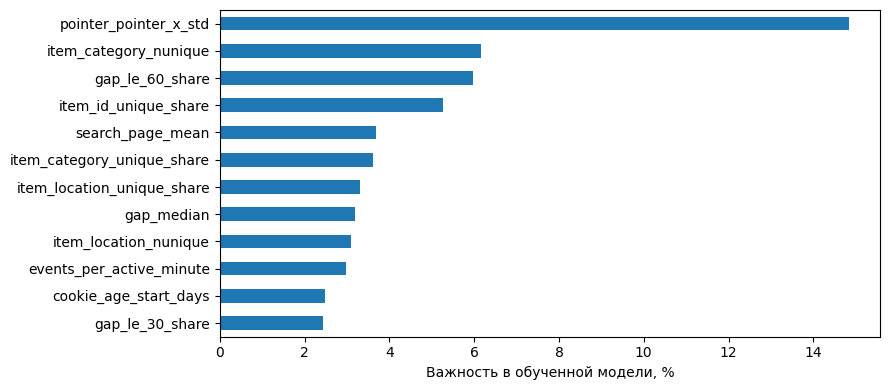

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,3674.0,540.923594,135.813795,0.000000,490.662946,552.050024,607.619287,1247.336362
1,250.0,219.609624,132.261472,8.485281,125.435212,200.551441,283.219196,813.596337


count      mean
platform_mode target                 
android       0        4310  1.000000
              1         285  1.000000
ios           0         553  1.000000
              1          26  1.000000
web           0        5329  0.287859
              1         588  0.573129

In [19]:
early_valid = folds[0][2]
early_op = operating_point(y[early_valid], predictions[best, 'earlier'])
late_pred = predictions[best, 'latest'] >= early_op['threshold']
transfer_tp = int((late_pred & (y[latest] == 1)).sum())
transfer = {'threshold_from_earlier_fold': early_op['threshold'],
    'latest_precision': transfer_tp / int(late_pred.sum()) if late_pred.sum() else np.nan,
    'latest_recall': transfer_tp / int(y[latest].sum())}
display(pd.Series(transfer).to_frame('value'))

selected_model = models[best, 'latest']
if config['kind'] == 'cat':
    importance = pd.Series(selected_model.feature_importances_, index=config['columns'], name='importance')
    display(importance.nlargest(15).to_frame())
    importance.nlargest(12).sort_values().plot.barh(figsize=(9, 4))
    plt.xlabel('Важность в обученной модели, %')
    plt.tight_layout()
    plt.show()

# Проверка сильного сигнала на train: сравниваем web-cookies с ≥2 наблюдениями координат.
train_audit = x.assign(target=y)
web_audit = train_audit.loc[train_audit.platform_mode.eq('web') & train_audit.pointer_observed_count.ge(2)]
display(web_audit.groupby('target').pointer_pointer_x_std.describe())
display(train_audit.assign(no_coordinates=train_audit.pointer_observed_count.eq(0)).groupby(
    ['platform_mode', 'target']).no_coordinates.agg(['count', 'mean']))

Перенос порога с раннего фолда даёт Precision=0,6575 при Recall=0,7438: рабочая точка меняется во времени.
Самый сильный признак — разброс X-координат (14,8% важности).
Он рассчитан внутри окна; среди web-cookies с ≥2 координатами его медиана — 552 у отрицательного
класса и 201 у положительного. Этот сигнал чувствителен к устройствам и способу сбора событий.

Дополнительно обучим выбранную конфигурацию на метках, перемешанных **внутри дат**.
Метрика около случайного уровня — полезная проверка, но не доказательство отсутствия любых смещений разметки.

In [20]:
if config['kind'] == 'cat':
    audit_y = y.copy()
    rng = np.random.default_rng(SEED)
    for date in train.window_start_ts.unique():
        indices = np.flatnonzero(train.window_start_ts == date)
        audit_y[indices] = rng.permutation(audit_y[indices])
    _, audit_pred, _, _ = fit_predict(config, x[config['columns']], audit_y, folds[-1][1], latest)
    display(pd.Series(evaluate(audit_y[latest], audit_pred), name='shuffled_labels').to_frame())

rng = np.random.default_rng(SEED)
valid_dates = train.window_start_ts.iloc[latest].to_numpy()
dates = np.unique(valid_dates)
bootstrap = []
for _ in range(300):
    indices = np.concatenate([np.flatnonzero(valid_dates == d)
        for d in rng.choice(dates, len(dates), replace=True)])
    bootstrap.append(precision_at_recall(y[latest][indices], predictions[best, 'latest'][indices]))
print('Bootstrap по дням, квантили 2,5% / 97,5%:', np.quantile(bootstrap, [.025, .975]))

Bootstrap по дням, квантили 2,5% / 97,5%: [0.66459627 0.78688525]


,shuffled_labels
precision_at_recall70,0.082769
average_precision,0.082862
roc_auc,0.486219


При перемешанных метках P@R≥0,70=0,0828, AUC=0,4862.
Bootstrap по дням даёт диапазон примерно 0,665–0,787, но основан всего на трёх днях
и условен относительно уже выбранной модели. Нельзя трактовать его как надёжную гарантию качества на test.

## 10. Финальное обучение и submission

Фиксируем победившие признаки и параметры до расчёта финальных тестовых оценок.
Число деревьев берём как целую медиану лучших итераций фолдов:
для текущих данных (762+555)/2 → **658**. Затем обучаем модель на всём train без early stopping по test.

Сохраняем непрерывный score, не метку 0/1. Не округляем и не добавляем искусственный шум для удаления совпадений.
Проверяем состав cookies, порядок sample_submission, уникальность, отсутствие NaN/inf и диапазон [0, 1].

In [21]:
iterations = int(np.median([r['iterations'] for r in results if r['experiment'] == best]))
cols = config['columns']
print('Итог:', best, '| признаков:', len(cols), '| итераций:', iterations)
if config['kind'] == 'cat':
    model = CatBoostClassifier(iterations=iterations, depth=config.get('depth', 5), learning_rate=.04,
        l2_leaf_reg=5, loss_function='Logloss', random_seed=SEED, thread_count=THREADS,
        allow_writing_files=False, verbose=False,
        auto_class_weights='Balanced' if config.get('balanced') else None,
        cat_features=list(x[cols].select_dtypes(include='object').columns))
    model.fit(prepare_cat(x[cols]), y)
else:
    model = selected_model
    model.fit(x[cols], y)

print('Собираем финальные признаки test...')
xt, _ = build_features(events, test)
xt = xt.reindex(columns=cols)
test_scores = model.predict_proba(prepare_cat(xt) if config['kind'] == 'cat' else xt)[:, 1]
submission = sample[['cookie_id']].merge(pd.DataFrame({'cookie_id': test.cookie_id, 'score': test_scores}),
    on='cookie_id', how='left', validate='one_to_one', sort=False)
validate_submission(submission, test, sample)
submission.to_csv('submission.csv', index=False)
validate_submission(pd.read_csv('submission.csv'), test, sample)
display(submission.head())
print('Сохранён submission.csv:', len(submission), 'строк')
print('Диапазон scores:', submission.score.min(), submission.score.max())
print('SHA-256:', hashlib.sha256(Path('submission.csv').read_bytes()).hexdigest())

Итог: cat_pointer | признаков: 69 | итераций: 658
Собираем финальные признаки test...
Сохранён submission.csv: 4909 строк
Диапазон scores: 0.00017457769595407175 0.9994554085223456
SHA-256: 30b43da21970e9d4f1d6b87885103059a0a74250ccb10d7ac322b77a5059ebe1


,cookie_id,score
0,ck_99a4e5ef02d89493,0.023017
1,ck_54d463f7fd89ec3d,0.019714
2,ck_0fbbc7a6af300368,0.003990
3,ck_8fd4937eadd64fb6,0.007049
4,ck_dbb4bd4eda97255d,0.014292


## 11. Воспроизводимость, источники и ограничения

Для воспроизведения достаточно этого ноутбука, исходных CSV, официального `metric.py` и зависимостей
из `requirements.txt`. Промежуточные признаки и модели не читаются с диска. Повторный запуск через
**Restart Kernel → Run All** создаёт submission заново; SHA-256 выше позволяет сравнить результат.
Проверки корректности выполняются в разделе 5; все таблицы экспериментов доступны в разделе 8.

Использованы open-source библиотеки NumPy, pandas, SciPy, scikit-learn, CatBoost, matplotlib,
IPython/ipykernel и их зависимости. Из предоставленных материалов заимствованы официальная метрика,
окно `[start, end)` и двухпризнаковый RandomForest quickstart. Остальное — стандартные подходы:
агрегирование событий, логистическая регрессия, бустинг, временная валидация и сравнение групп признаков.
Внешние данные и готовые ответы для cookies не использовались.

Оба временных фолда участвовали в выборе модели; отдельного нетронутого holdout здесь нет.
Положительный класс охватывает известные сервисы сбора данных, а отрицательный считается человеческим.
Перенос на новые сервисы отдельно не проверен из-за отсутствия их идентификаторов.
Малоактивные боты и изменение механизма сбора координат остаются основными ограничениями решения.

### Проверка переноса в ноутбук

Все 21 кодовые ячейки последовательно выполнены в чистом процессе IPython в отдельном каталоге только с исходными данными и официальной метрикой. Таблицы и графики сохранены в выводах; 7 встроенных тестов прошли. Полученный CSV побайтово совпал с ранее проверенным решением. Запуск через отдельное Jupyter-ядро в этой среде не проверен: локальные сокеты ограничены.

Контрольная сумма `submission.csv` (SHA-256): `30b43da21970e9d4f1d6b87885103059a0a74250ccb10d7ac322b77a5059ebe1`.